In [31]:
import os
import datajoint as dj
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# change to the upper level folder to detect dj_local_conf.json
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
dj.config.load("/home/sgao/source/spyglass/notebooks/dj_local_conf.json")  # load config for database connection info

import spyglass.common as sgc
import spyglass.position.v1 as sgp
import spyglass.lfp.analysis.v1 as lfp_analysis
from spyglass.lfp import LFPOutput
import spyglass.lfp as sglfp
import spyglass.lfp as lfp
from spyglass.position import PositionOutput
from spyglass.lfp.v1.lfp_artifact import (
    LFPArtifactDetection,
    LFPArtifactDetectionParameters,
    LFPArtifactDetectionSelection,
)
import spyglass.ripple.v1 as sgrip
import spyglass.ripple.v1 as sgr

# ignore datajoint+jupyter async warnings
import warnings

warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", category=ResourceWarning)

[2026-10-07 13:22:49,661][INFO]: DataJoint is configured from /home/sgao/source/spyglass/notebooks/dj_local_conf.json


In [32]:
import pynwb

nwb_file_name = "Embry20260604_.nwb"

io = pynwb.NWBHDF5IO(
    "/stelmo/nwb/raw/Embry20260604_.nwb",
    mode="r"
)

nwbf = io.read()

In [33]:
import pandas as pd

nwb_file_name = "Embry20260604_.nwb"

sleep_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6",
]

results = []

for session_number, session in enumerate(sleep_sessions, start=1):

    ripple_times = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
            "group_name": "CA1 Pyramidal Layer",
        }
    ).fetch1_dataframe()

    results.append({
        "session_number": session_number,
        "session": session,
        "n_ripples": len(ripple_times),
    })

ripple_counts = pd.DataFrame(results)

ripple_counts

,session_number,session,n_ripples
0,1,01_s1,2157
1,2,03_s2,3079
2,3,05_s3,3223
3,4,07_s4,3000
4,5,09_s5,3226
5,6,11_s6,3012


In [34]:
for session in sleep_sessions:
    rel = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
        }
    )

    print(session, len(rel))

01_s1 1
03_s2 1
05_s3 1
07_s4 1
09_s5 1
11_s6 2


In [35]:
(
    sgrip.RippleTimesV1()
    & {
        "nwb_file_name": nwb_file_name,
        "target_interval_list_name": "11_s6",
        "ripple_param_name": "default_trodes",
    }
).fetch(as_dict=True)

[{'lfp_merge_id': UUID('d8480f89-1050-98ca-b0b8-f9efa639a7d7'),
  'filter_name': 'Ripple 150-250 Hz DMR',
  'filter_sampling_rate': 1034,
  'nwb_file_name': 'Embry20260604_.nwb',
  'target_interval_list_name': '11_s6',
  'lfp_band_sampling_rate': 1034,
  'group_name': 'CA1 Pyramidal Layer',
  'ripple_param_name': 'default_trodes',
  'pos_merge_id': UUID('d7bbad12-5aae-268d-77b3-e8b5216336fb'),
  'analysis_file_name': 'Embry20260604_HSVUBWXUKS.nwb',
  'ripple_times_object_id': '0f1cb6e6-e4f0-4122-a7f8-c8152d988fa0'},
 {'lfp_merge_id': UUID('d8480f89-1050-98ca-b0b8-f9efa639a7d7'),
  'filter_name': 'Ripple 150-250 Hz DMR',
  'filter_sampling_rate': 1034,
  'nwb_file_name': 'Embry20260604_.nwb',
  'target_interval_list_name': '11_s6',
  'lfp_band_sampling_rate': 1034,
  'group_name': 'Ripple Detection Channels',
  'ripple_param_name': 'default_trodes',
  'pos_merge_id': UUID('d7bbad12-5aae-268d-77b3-e8b5216336fb'),
  'analysis_file_name': 'Embry20260604_222W0W6XSC.nwb',
  'ripple_times_obj

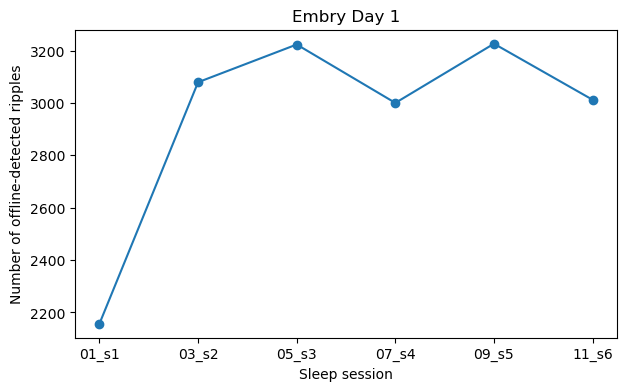

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(
    ripple_counts["session"],
    ripple_counts["n_ripples"],
    marker="o"
)

plt.xlabel("Sleep session")
plt.ylabel("Number of offline-detected ripples")
plt.title("Embry Day 1")

plt.show()

In [37]:
import pandas as pd

nwb_file_name = "Embry20260604_.nwb"

sleep_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6"
]

results = []

for session_number, session in enumerate(sleep_sessions, start=1):

    ripple_times = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
            "group_name": "CA1 Pyramidal Layer",
        }
    ).fetch1_dataframe()

    n_ripples = len(ripple_times)

    first_ripple = ripple_times["start_time"].min()
    last_ripple = ripple_times["end_time"].max()

    duration_sec = last_ripple - first_ripple
    duration_min = duration_sec / 60

    ripple_rate = n_ripples / duration_min

    results.append({
        "session_number": session_number,
        "session": session,
        "n_ripples": n_ripples,
        "duration_min": duration_min,
        "ripples_per_min": ripple_rate,
    })

ripple_summary = pd.DataFrame(results)

ripple_summary

,session_number,session,n_ripples,duration_min,ripples_per_min
0,1,01_s1,2157,39.895298,54.066522
1,2,03_s2,3079,40.102591,76.778081
2,3,05_s3,3223,40.026111,80.522437
3,4,07_s4,3000,39.955773,75.083017
4,5,09_s5,3226,40.005944,80.638016
5,6,11_s6,3012,41.665694,72.289687


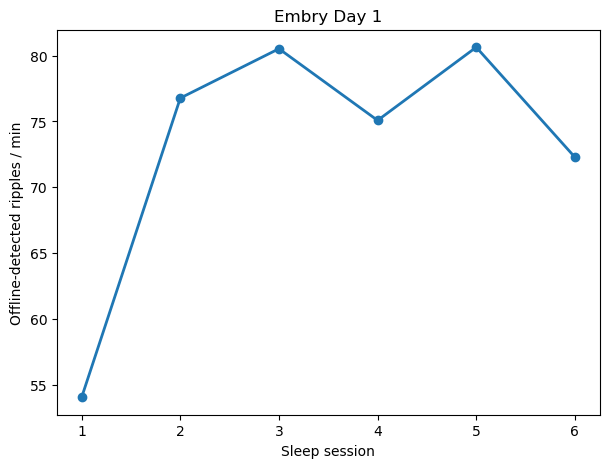

In [38]:
import matplotlib.pyplot as plt

ripple_summary["session_number"] = [1, 2, 3, 4, 5, 6]

plt.figure(figsize=(7, 5))

plt.plot(
    ripple_summary["session_number"],
    ripple_summary["ripples_per_min"],
    marker="o",
    linewidth=2
)

plt.xlabel("Sleep session")
plt.ylabel("Offline-detected ripples / min")
plt.title("Embry Day 1")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.show()
ripple_summary_day1 = ripple_summary.copy()
ripple_summary.to_csv("embry_ripple_summary.csv", index=False)

duration

In [39]:
import pandas as pd

nwb_file_name = "Embry20260604_.nwb"

sleep_sessions = [
    "01_s1",
    "03_s2",
    "05_s3",
    "07_s4",
    "09_s5",
    "11_s6"
]

all_ripples = []

for session_number, session in enumerate(sleep_sessions, start=1):

    ripple_times = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
            "group_name": "CA1 Pyramidal Layer",
        }
    ).fetch1_dataframe().copy()

    ripple_times["session_number"] = session_number
    ripple_times["session"] = session

    all_ripples.append(ripple_times)

all_ripples = pd.concat(all_ripples, ignore_index=True)

all_ripples

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed,session_number,session
0,1.780596e+09,1.780596e+09,0.105369,2.790871,1.348181,0.816621,5.256470,0.100952,0.142980,0.394408,3.742431,3.318021,3.742431,3.318021,3.380920,3.431112,1,01_s1
1,1.780596e+09,1.780596e+09,0.063801,2.787734,1.689131,1.373446,3.975411,0.026479,0.109361,0.290312,0.984476,3.077344,3.077344,0.984476,2.075420,2.049695,1,01_s1
2,1.780596e+09,1.780596e+09,0.061868,2.679102,1.557478,1.098431,4.165602,0.004530,0.097834,0.277301,1.517545,0.637118,1.517545,0.637118,0.852533,0.935731,1,01_s1
3,1.780596e+09,1.780596e+09,0.087968,2.332895,1.565574,1.244806,3.507093,0.021869,0.139202,0.346986,0.681723,0.923559,0.923559,0.516335,0.601197,0.633376,1,01_s1
4,1.780596e+09,1.780596e+09,0.107302,2.908669,1.241661,0.686753,4.187635,0.017105,0.134414,0.324615,0.956692,1.026244,1.026244,0.608413,0.762600,0.779988,1,01_s1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17692,1.780617e+09,1.780617e+09,0.086035,4.533516,2.216458,1.532622,6.350337,0.003589,0.192829,0.745019,0.033282,0.039920,0.039920,0.033282,0.034217,0.035026,6,11_s6
17693,1.780617e+09,1.780617e+09,0.064768,2.741321,1.587241,1.262049,3.607599,0.023164,0.104302,0.257426,0.041903,0.038578,0.041903,0.038578,0.039499,0.039735,6,11_s6
17694,1.780617e+09,1.780617e+09,0.055101,2.321488,1.447851,0.898960,3.593707,0.020017,0.081134,0.198682,0.110757,0.126840,0.127501,0.110757,0.123507,0.121954,6,11_s6
17695,1.780617e+09,1.780617e+09,0.062835,2.531494,1.611928,1.142138,4.156902,0.033249,0.102801,0.269541,0.075346,0.591095,0.591095,0.075346,0.266927,0.288973,6,11_s6


In [40]:
all_ripples["duration_ms"] = (
    all_ripples["end_time"] - all_ripples["start_time"]
) * 1000

duration_summary = (
    all_ripples
    .groupby("session_number")["duration_ms"]
    .agg(
        n="count",
        median="median",
        mean="mean",
        std="std"
    )
    .reset_index()
)

duration_summary
duration_summary.to_csv("embry_duration_summary.csv", index=False)

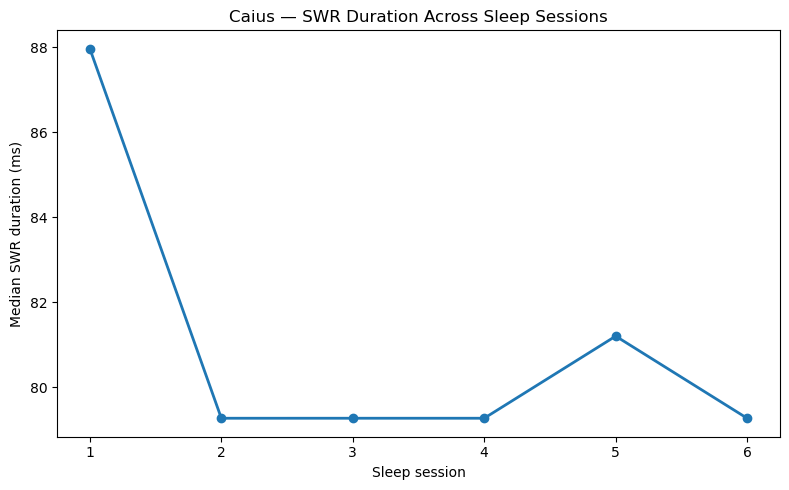

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    duration_summary["session_number"],
    duration_summary["median"],
    marker="o",
    linewidth=2
)

plt.xlabel("Sleep session")
plt.ylabel("Median SWR duration (ms)")
plt.title("Caius — SWR Duration Across Sleep Sessions")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.tight_layout()
plt.show()

In [42]:
amplitude_summary = (
    all_ripples
    .groupby("session_number")["max_zscore"]
    .agg(
        n="count",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        mean="mean",
        std="std"
    )
    .reset_index()
)

amplitude_summary["IQR"] = (
    amplitude_summary["q75"] -
    amplitude_summary["q25"]
)

amplitude_summary
amplitude_summary.to_csv("embry_amplitude_summary.csv", index=False)

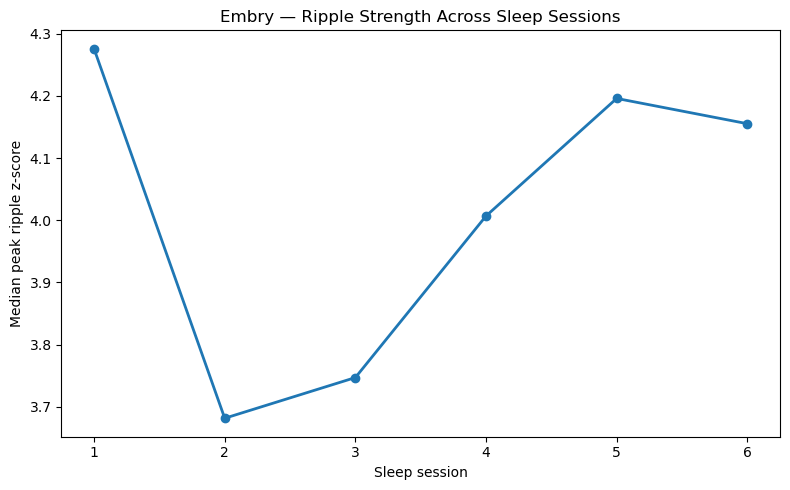

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    amplitude_summary["session_number"],
    amplitude_summary["median"],
    marker="o",
    linewidth=2
)

plt.xlabel("Sleep session")
plt.ylabel("Median peak ripple z-score")
plt.title("Embry — Ripple Strength Across Sleep Sessions")

plt.xticks([1, 2, 3, 4, 5, 6])

plt.tight_layout()
plt.show()

In [49]:
import pandas as pd
import numpy as np

def calculate_session_detection_stats(
    nwb_file_name,
    nwbf,
    sessions
):
    
    # Get laser data once
    laser = (
        nwbf.processing["behavior"]
        .data_interfaces["behavioral_events"]
        .time_series["Laser"]
    )
    
    laser_data = laser.data[:]
    laser_timestamps = laser.timestamps[:]
    
    results = []

    for epoch_number, session in sessions.items():

        print(f"Processing {session}...")

        # =================================================
        # ONLINE
        # =================================================
        epoch_start, epoch_stop, epoch_name = (
            nwbf.intervals["epochs"][epoch_number].to_numpy()[0]
        )

        mask = (
            (laser_timestamps > epoch_start) &
            (laser_timestamps <= epoch_stop)
        )

        laser_data_epoch = laser_data[mask]
        laser_timestamps_epoch = laser_timestamps[mask]

        # OFF -> ON transitions
        rising_edge_idx = np.where(
            np.diff(laser_data_epoch, prepend=0) == 1
        )[0]

        pulse_start_times = (
            laser_timestamps_epoch[rising_edge_idx]
        )

        # 20 pulses = one online train
        n_complete_trains = len(pulse_start_times) // 20

        online_trains = pulse_start_times[
            :n_complete_trains * 20
        ].reshape(
            n_complete_trains,
            20
        )

        # =================================================
        # OFFLINE
        # =================================================
        offline = (
            sgrip.RippleTimesV1()
            & {
                "nwb_file_name": nwb_file_name,
                "target_interval_list_name": session,
                "ripple_param_name": "default_trodes",
                "group_name": "CA1 Pyramidal Layer"
            }
        ).fetch1_dataframe()

        offline_start = offline["start_time"].to_numpy()
        offline_end = offline["end_time"].to_numpy()

        # =================================================
        # OFFLINE -> ONLINE MATCHING
        # Same logic as Marcus notebook
        # =================================================
        offline_has_online_match = []

        for start, end in zip(
            offline_start,
            offline_end
        ):

            pulse_matches = (
                (online_trains >= start) &
                (online_trains <= end)
            )

            offline_has_online_match.append(
                np.any(pulse_matches)
            )

        offline_has_online_match = np.array(
            offline_has_online_match
        )

        # =================================================
        # SUMMARY
        # =================================================
        n_offline = len(offline)
        n_online = len(online_trains)

        n_tp = offline_has_online_match.sum()
        n_fn = n_offline - n_tp

        capture_pct = (
            100 * n_tp / n_offline
            if n_offline > 0
            else np.nan
        )

        missed_pct = (
            100 * n_fn / n_offline
            if n_offline > 0
            else np.nan
        )

        results.append({
            "session": session,
            "offline_swr": n_offline,
            "online_detection": n_online,
            "TP": n_tp,
            "FN": n_fn,
            "capture_pct": capture_pct,
            "missed_pct": missed_pct
        })

        print(
            f"  Offline = {n_offline}, "
            f"Online = {n_online}, "
            f"TP = {n_tp}, "
            f"FN = {n_fn}, "
            f"Capture = {capture_pct:.1f}%"
        )

    return pd.DataFrame(results)

In [50]:
embry_sessions = {
    0: "01_s1",
    2: "03_s2",
    4: "05_s3",
    6: "07_s4",
    8: "09_s5",
    10: "11_s6",
}

In [51]:
import numpy as np
import pynwb
import spyglass.common as sgc

#this reads the raw nwb file so we can get laser DIO times
io = pynwb.NWBHDF5IO("/stelmo/nwb/raw/Embry20260604.nwb", mode="r")
nwbf = io.read()

In [52]:
embry_stats = calculate_session_detection_stats(
    "Embry20260604_.nwb",
    nwbf,
    embry_sessions
)

embry_stats

Processing 01_s1...
  Offline = 2157, Online = 2, TP = 0, FN = 2157, Capture = 0.0%
Processing 03_s2...
  Offline = 3079, Online = 2732, TP = 2229, FN = 850, Capture = 72.4%
Processing 05_s3...
  Offline = 3223, Online = 2489, TP = 1982, FN = 1241, Capture = 61.5%
Processing 07_s4...
  Offline = 3000, Online = 2248, TP = 1963, FN = 1037, Capture = 65.4%
Processing 09_s5...
  Offline = 3226, Online = 2920, TP = 2484, FN = 742, Capture = 77.0%
Processing 11_s6...
  Offline = 3012, Online = 2420, TP = 2080, FN = 932, Capture = 69.1%


,session,offline_swr,online_detection,TP,FN,capture_pct,missed_pct
0,01_s1,2157,2,0,2157,0.000000,100.000000
1,03_s2,3079,2732,2229,850,72.393634,27.606366
2,05_s3,3223,2489,1982,1241,61.495501,38.504499
3,07_s4,3000,2248,1963,1037,65.433333,34.566667
4,09_s5,3226,2920,2484,742,76.999380,23.000620
5,11_s6,3012,2420,2080,932,69.057105,30.942895


In [ ]:
# embry_stats.to_csv("embry_online_offline_stats.csv", index=False)

In [55]:
# ============================================================
# Load Embry laser data
# ============================================================

laser = (
    nwbf.processing["behavior"]
    .data_interfaces["behavioral_events"]
    .time_series["Laser"]
)

laser_data = laser.data[:]
laser_timestamps = laser.timestamps[:]

print("Laser samples:", len(laser_data))
print("Laser timestamps:", len(laser_timestamps))

Laser samples: 512451
Laser timestamps: 512451


In [56]:
import pandas as pd
import numpy as np

# ============================================================
# EMBRY — FIRST-PULSE ALIGNMENT ANALYSIS
# ============================================================

embry_firstpulse_all_stats = []

for session_number, session in enumerate(sleep_sessions, start=1):

    print(f"Processing Embry {session}...")

    # ==================================================
    # 1. Offline SWRs
    # ==================================================
    offline_ripples_embry_firstpulse = (
        sgrip.RippleTimesV1()
        & {
            "nwb_file_name": nwb_file_name,
            "target_interval_list_name": session,
            "ripple_param_name": "default_trodes",
            "group_name": "CA1 Pyramidal Layer"
        }
    ).fetch1_dataframe()

    n_offline = len(
        offline_ripples_embry_firstpulse
    )

    # ==================================================
    # 2. Get session epoch
    # ==================================================
    epoch_index = (session_number - 1) * 2

    epoch_start, epoch_stop, _ = (
        nwbf.intervals["epochs"][epoch_index]
        .to_numpy()[0]
    )

    # ==================================================
    # 3. Extract laser signal
    # ==================================================
    laser_mask = (
        (laser_timestamps >= epoch_start) &
        (laser_timestamps <= epoch_stop)
    )

    laser_session = laser_data[laser_mask]
    laser_times_session = laser_timestamps[laser_mask]

    # ==================================================
    # 4. Find rising edges
    # ==================================================
    rising_edges = (
        np.diff(
            laser_session.astype(int)
        ) == 1
    )

    pulse_start_times = (
        laser_times_session[1:][rising_edges]
    )

    # ==================================================
    # 5. Group every 20 pulses into trains
    # ==================================================
    n_complete_trains = len(pulse_start_times) // 20

    if n_complete_trains > 0:

        online_trains = (
            pulse_start_times[
                :n_complete_trains * 20
            ]
            .reshape(
                n_complete_trains,
                20
            )
        )

    else:

        online_trains = np.empty((0, 20))

    n_online = len(online_trains)

    # ==================================================
    # 6. FIRST-PULSE MATCHING
    # ==================================================
    offline_starts = (
        offline_ripples_embry_firstpulse["start_time"]
        .to_numpy()
    )

    offline_ends = (
        offline_ripples_embry_firstpulse["end_time"]
        .to_numpy()
    )

    # Only the first pulse from each train
    first_pulses = online_trains[:, 0]

    first_pulse_match = np.zeros(
        n_offline,
        dtype=bool
    )

    for i, (start, end) in enumerate(
        zip(
            offline_starts,
            offline_ends
        )
    ):

        first_pulse_match[i] = np.any(
            (first_pulses >= start) &
            (first_pulses <= end)
        )

    # ==================================================
    # 7. TP / FN
    # ==================================================
    embry_firstpulse_tp = int(
        first_pulse_match.sum()
    )

    embry_firstpulse_fn = (
        n_offline -
        embry_firstpulse_tp
    )

    # ==================================================
    # 8. Percentages
    # ==================================================
    embry_firstpulse_capture_pct = (
        100 * embry_firstpulse_tp / n_offline
        if n_offline > 0
        else np.nan
    )

    embry_firstpulse_missed_pct = (
        100 * embry_firstpulse_fn / n_offline
        if n_offline > 0
        else np.nan
    )

    # ==================================================
    # 9. Save results
    # ==================================================
    embry_firstpulse_all_stats.append({
        "session_number": session_number,
        "session": session,
        "offline_swr": n_offline,
        "online_detection": n_online,
        "TP_firstpulse": embry_firstpulse_tp,
        "FN_firstpulse": embry_firstpulse_fn,
        "capture_pct_firstpulse": embry_firstpulse_capture_pct,
        "missed_pct_firstpulse": embry_firstpulse_missed_pct
    })

    print(
        f"  Offline: {n_offline} | "
        f"Online: {n_online} | "
        f"TP (1st pulse): {embry_firstpulse_tp} | "
        f"FN: {embry_firstpulse_fn} | "
        f"Capture: {embry_firstpulse_capture_pct:.1f}%"
    )

# ============================================================
# Final Embry first-pulse table
# ============================================================

embry_firstpulse_stats = pd.DataFrame(
    embry_firstpulse_all_stats
)

embry_firstpulse_stats

Processing Embry 01_s1...
  Offline: 2157 | Online: 2 | TP (1st pulse): 0 | FN: 2157 | Capture: 0.0%
Processing Embry 03_s2...
  Offline: 3079 | Online: 2732 | TP (1st pulse): 1968 | FN: 1111 | Capture: 63.9%
Processing Embry 05_s3...
  Offline: 3223 | Online: 2489 | TP (1st pulse): 1746 | FN: 1477 | Capture: 54.2%
Processing Embry 07_s4...
  Offline: 3000 | Online: 2248 | TP (1st pulse): 1746 | FN: 1254 | Capture: 58.2%
Processing Embry 09_s5...
  Offline: 3226 | Online: 2920 | TP (1st pulse): 2157 | FN: 1069 | Capture: 66.9%
Processing Embry 11_s6...
  Offline: 3012 | Online: 2420 | TP (1st pulse): 1832 | FN: 1180 | Capture: 60.8%


,session_number,session,offline_swr,online_detection,TP_firstpulse,FN_firstpulse,capture_pct_firstpulse,missed_pct_firstpulse
0,1,01_s1,2157,2,0,2157,0.000000,100.000000
1,2,03_s2,3079,2732,1968,1111,63.916856,36.083144
2,3,05_s3,3223,2489,1746,1477,54.173131,45.826869
3,4,07_s4,3000,2248,1746,1254,58.200000,41.800000
4,5,09_s5,3226,2920,2157,1069,66.862988,33.137012
5,6,11_s6,3012,2420,1832,1180,60.823373,39.176627


In [58]:
embry_firstpulse_mean = embry_firstpulse_stats.loc[
    embry_firstpulse_stats["session_number"] != 1,
    "capture_pct_firstpulse"
].mean()

print(
    f"Embry mean first-pulse capture (S2-S6): "
    f"{embry_firstpulse_mean:.1f}%"
)

Embry mean first-pulse capture (S2-S6): 60.8%


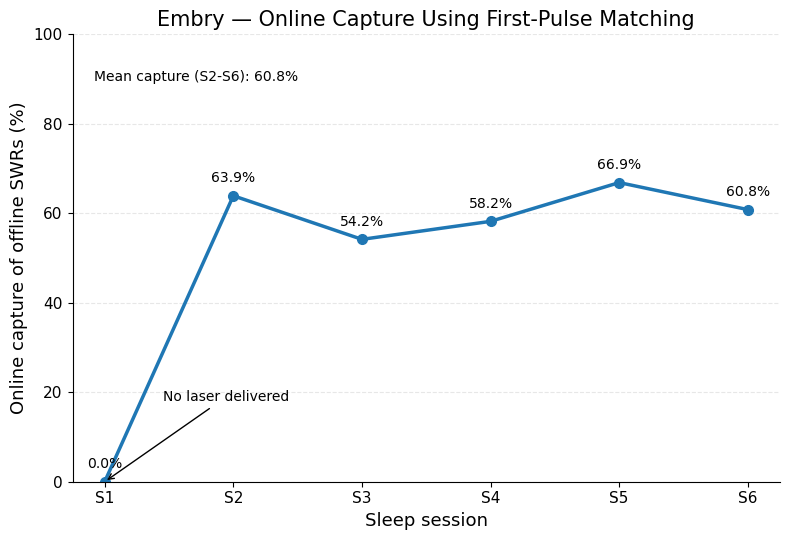

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5.5))

plt.plot(
    embry_firstpulse_stats["session_number"],
    embry_firstpulse_stats["capture_pct_firstpulse"],
    marker="o",
    markersize=7,
    linewidth=2.5
)

plt.annotate(
    "No laser delivered",
    xy=(1, 0),
    xytext=(1.45, 18),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1
    ),
    fontsize=10
)

plt.text(
    0.03,
    0.92,
    f"Mean capture (S2-S6): {embry_firstpulse_mean:.1f}%",
    transform=plt.gca().transAxes,
    fontsize=10,
    ha="left",
    va="top"
)

plt.xlabel(
    "Sleep session",
    fontsize=13
)

plt.ylabel(
    "Online capture of offline SWRs (%)",
    fontsize=13
)

plt.title(
    "Embry — Online Capture Using First-Pulse Matching",
    fontsize=15
)

plt.xticks(
    [1, 2, 3, 4, 5, 6],
    ["S1", "S2", "S3", "S4", "S5", "S6"],
    fontsize=11
)

plt.yticks(
    range(0, 101, 20),
    fontsize=11
)

plt.ylim(0, 100)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

for x, y in zip(
    embry_firstpulse_stats["session_number"],
    embry_firstpulse_stats["capture_pct_firstpulse"]
):
    plt.text(
        x,
        y + 3,
        f"{y:.1f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
# embry_firstpulse_stats.to_csv(
    "Embry_first_pulse_online_offline_stats.csv",
    index=False
)

print("Saved: Embry_first_pulse_online_offline_stats.csv")

Saved: Embry_first_pulse_online_offline_stats.csv
